Loading data from /content/drive/MyDrive/dataset/final_preprocessed_balanced.csv...
Data loaded successfully.

Data Shape: (238518, 14)
Columns: ['url_length_category', 'hostname_length', 'length_features_std', 'url_segments', 'count_features_std', 'url_complexity', 'count_underscore_log', 'URL_encoded_log', 'query_params_count', 'URL_encoded', 'count_dash_log', 'subdomain_count', 'Label_encoded', 'Label']

Label Distribution:
 Label_encoded
0    119259
1    119259
Name: count, dtype: int64

First 5 rows:
   url_length_category  hostname_length  length_features_std  url_segments  \
0                  1.0         0.000000                 1.76           1.0   
1                  0.0         0.428571                 0.80           0.0   
2                  0.0         1.428571                -0.44          -0.5   
3                  1.0         1.857143                 0.44           0.0   
4                  0.0         0.571429                 0.76           2.0   

   count_features_st

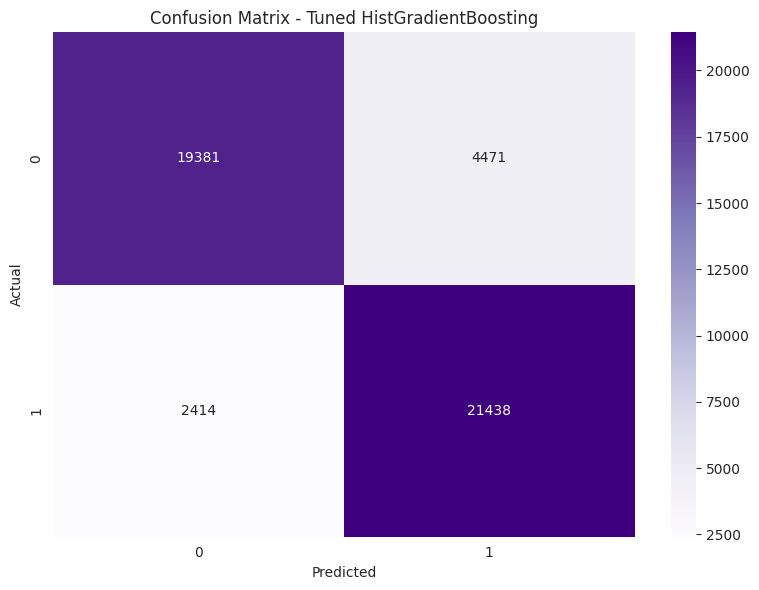


Plotting ROC Curve...


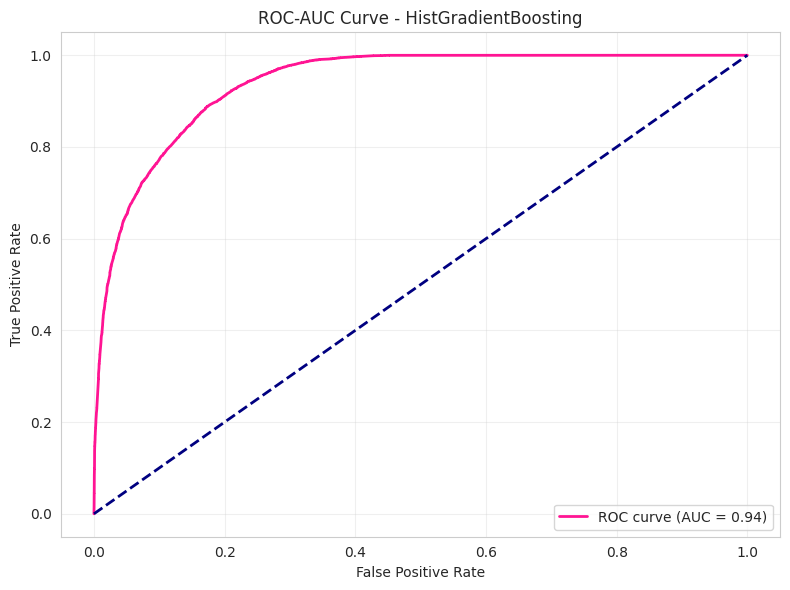


Plotting Feature Importance...


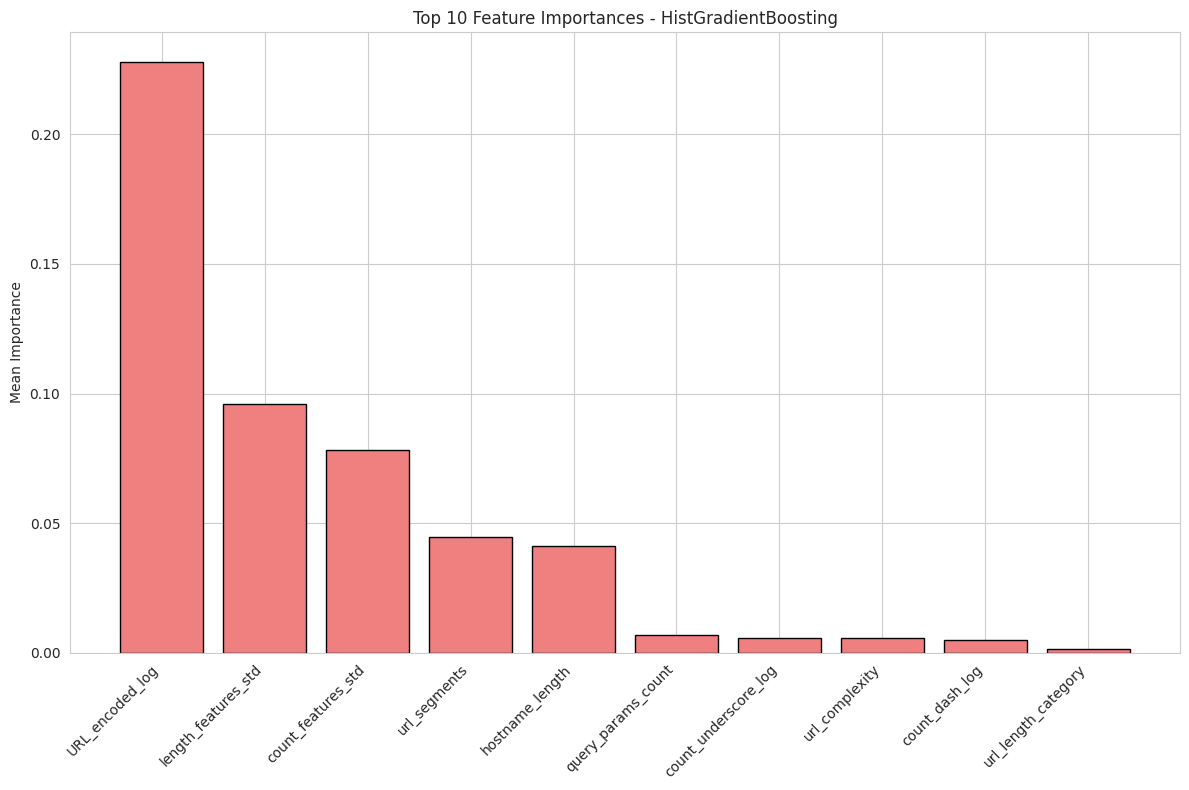


--- Performing Stratified 5-Fold Cross-Validation ---
🔹 5-Fold Cross-Validation Results
------------------------------------------------------------
Fold 1: AUC = 0.9379, Accuracy = 0.8540
Fold 2: AUC = 0.9377, Accuracy = 0.8544
Fold 3: AUC = 0.9376, Accuracy = 0.8531
Fold 4: AUC = 0.9388, Accuracy = 0.8579
Fold 5: AUC = 0.9383, Accuracy = 0.8561
------------------------------------------------------------
Mean AUC: 0.9381 (+/- 0.0009)
Mean Accuracy: 0.8551 (+/- 0.0034)


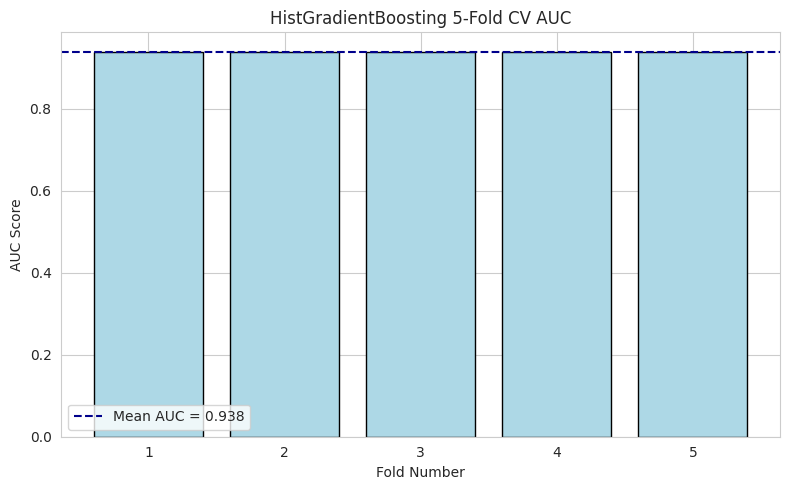


✅ Script execution complete.


In [2]:
"""
Optimized Gradient Boosting Classifier Training
(Fast Version using HistGradientBoostingClassifier)
"""

# ## 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    log_loss,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# ## 2. Load Data
FILE_PATH = '/content/drive/MyDrive/dataset/final_preprocessed_balanced.csv'
print(f"Loading data from {FILE_PATH}...")

data = pd.read_csv(FILE_PATH)
print("Data loaded successfully.\n")

print(f"Data Shape: {data.shape}")
print("Columns:", data.columns.tolist())

if 'Label_encoded' not in data.columns:
    raise ValueError("Error: Target column 'Label_encoded' not found.")

print("\nLabel Distribution:\n", data['Label_encoded'].value_counts())
print("\nFirst 5 rows:")
print(data.head())

# ## 3. Preprocessing
print("\nStarting preprocessing...")

if 'Label' in data.columns:
    print("Dropping redundant 'Label' column.")
    data = data.drop(columns=['Label'])

X = data.drop(columns=['Label_encoded'])
y = data['Label_encoded']
feature_names = X.columns.tolist()

if X.isnull().sum().sum() > 0:
    print("Filling missing values with mean.")
    X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Preprocessing complete.")

# ## 4. Train-Test Split
print("\nSplitting into Train/Test sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ## 5. Faster Hyperparameter Tuning
print("\nStarting Faster Hyperparameter Tuning...")

gb_base = HistGradientBoostingClassifier(random_state=42, early_stopping=True)

param_dist = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, None],
    'max_leaf_nodes': [31, 63, 127],
    'min_samples_leaf': [20, 30],
    'l2_regularization': [0.0, 0.1, 0.5],
}

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

best_gb_model = gb_search.best_estimator_
print("\n✅ Tuning complete.")
print(f"Best AUC: {gb_search.best_score_:.4f}")
print("Best Params:", gb_search.best_params_)

# ## 6. Model Evaluation
print("\n--- Evaluating Tuned Gradient Boosting Model ---")

y_pred = best_gb_model.predict(X_test)
y_proba = best_gb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, best_gb_model.predict_proba(X_test))
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss: {loss:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ## 7. Visualizations

# Confusion Matrix
print("\nPlotting Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned HistGradientBoosting")
plt.tight_layout()
plt.show()

# ROC Curve
print("\nPlotting ROC Curve...")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='deeppink', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - HistGradientBoosting')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Importance (permutation-based)
print("\nPlotting Feature Importance...")
from sklearn.inspection import permutation_importance

result = permutation_importance(best_gb_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[::-1]
top_features = np.array(feature_names)[sorted_idx][:10]

plt.figure(figsize=(12, 8))
plt.bar(range(len(top_features)), result.importances_mean[sorted_idx][:10], color='lightcoral', edgecolor='black')
plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right')
plt.title("Top 10 Feature Importances - HistGradientBoosting")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

# ## 8. Stratified K-Fold Cross-Validation
print("\n--- Performing Stratified 5-Fold Cross-Validation ---")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_auc = cross_val_score(best_gb_model, X_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_scores_acc = cross_val_score(best_gb_model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("🔹 5-Fold Cross-Validation Results")
print("-" * 60)
for i, (auc_s, acc_s) in enumerate(zip(cv_scores_auc, cv_scores_acc), 1):
    print(f"Fold {i}: AUC = {auc_s:.4f}, Accuracy = {acc_s:.4f}")
print("-" * 60)
print(f"Mean AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std() * 2:.4f})")
print(f"Mean Accuracy: {cv_scores_acc.mean():.4f} (+/- {cv_scores_acc.std() * 2:.4f})")

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, 6), cv_scores_auc, color='lightblue', edgecolor='black')
plt.axhline(cv_scores_auc.mean(), color='darkblue', linestyle='--', label=f'Mean AUC = {cv_scores_auc.mean():.3f}')
plt.title("HistGradientBoosting 5-Fold CV AUC")
plt.xlabel("Fold Number")
plt.ylabel("AUC Score")
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Script execution complete.")
